In [ ]:
!pip install imagehash

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import random
from pathlib import Path

In [ ]:
hash_df = pd.read_csv("/content/drive/MyDrive/copydays-ndid/image_hashes.csv")
hash_df.head()

,path,aHash,dHash,pHash
0,/content/drive/MyDrive/copydays-ndid/dataset/1...,ffffff0100000000,fefc76139ddec0c0,a18ddef0604f9db0
1,/content/drive/MyDrive/copydays-ndid/dataset/1...,000d2b7d0dbbc3c1,645b5acadb639b9b,bb0f708e72cc8d70
2,/content/drive/MyDrive/copydays-ndid/dataset/1...,3c250b3b030101ff,d5d55b63cf4f4b10,a70ad422d52fd479
3,/content/drive/MyDrive/copydays-ndid/dataset/1...,00000010bfbf7f63,958ac6e26a6aeac2,8d72709f6044afd3
4,/content/drive/MyDrive/copydays-ndid/dataset/1...,fffffbfbffff0000,60b23a5acb8484eb,e9c916d64325ea2b


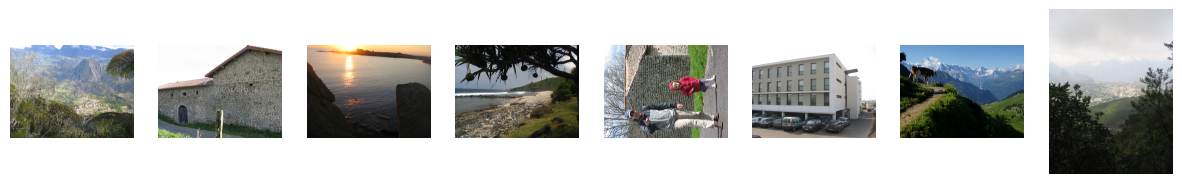

In [ ]:
def show_random_images(df, n=8):
    sample = df.sample(n)
    plt.figure(figsize=(15, 3))
    for i, row in enumerate(sample.itertuples()):
        img = Image.open(row.path)
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis('off')
    plt.show()

show_random_images(hash_df)

In [ ]:
import imagehash

def hamming(h1, h2):
    return imagehash.hex_to_hash(h1) - imagehash.hex_to_hash(h2)


def show_hash_neighbors(query_idx, df, k=5):
    q = df.iloc[query_idx]
    dists = []
    for i, row in df.iterrows():
        if i == query_idx: continue
        d = hamming(q.pHash, row.pHash)
        dists.append((d, row.path))

    dists.sort(key=lambda x: x[0])
    neighbors = dists[:k]

    plt.figure(figsize=(15,3))

    qimg = Image.open(q.path)
    plt.subplot(1, k+1, 1)
    plt.imshow(qimg)
    plt.axis('off')
    plt.title("Query")

    for i, (d, path) in enumerate(neighbors):
        img = Image.open(path)
        plt.subplot(1, k+1, i+2)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"d={d}")

    plt.show()

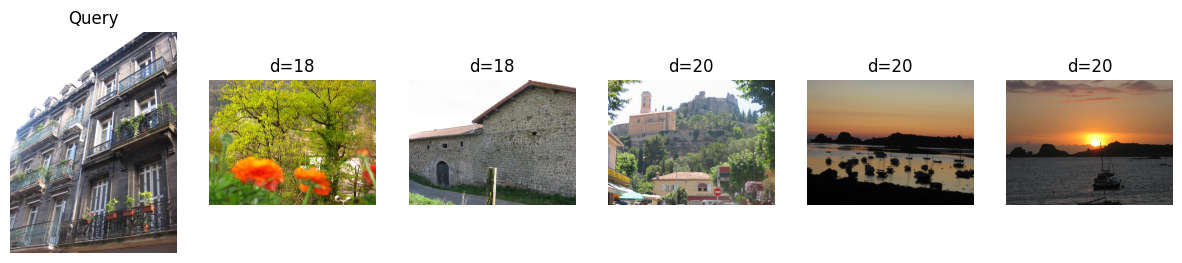

In [ ]:
idx = random.randint(0, len(hash_df)-1)
show_hash_neighbors(idx, hash_df)

In [ ]:
def manual_check(path1, path2):
    img1 = Image.open(path1)
    img2 = Image.open(path2)

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(img1)
    plt.axis('off')
    plt.title("Image A")

    plt.subplot(1,2,2)
    plt.imshow(img2)
    plt.axis('off')
    plt.title("Image B")

    plt.show()

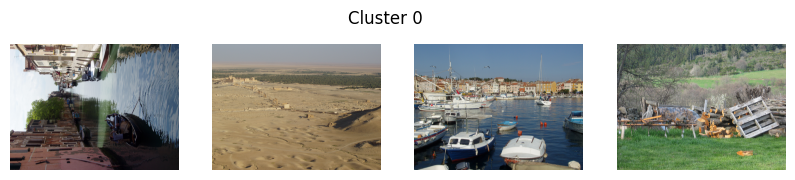

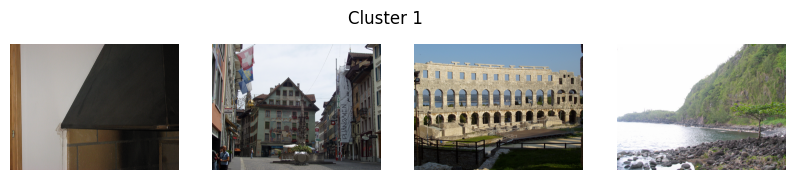

In [ ]:
# Placeholder: cluster_id → [paths]
clusters = {
    0: hash_df.sample(4).path.tolist(),
    1: hash_df.sample(4).path.tolist()
}

for cid, paths in clusters.items():
    plt.figure(figsize=(10,2))
    for i, p in enumerate(paths):
        img = Image.open(p)
        plt.subplot(1, len(paths), i+1)
        plt.imshow(img)
        plt.axis('off')
    plt.suptitle(f"Cluster {cid}")
    plt.show()